In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

# --- PFAD-CHECK ---
# Wir nutzen den absoluten Pfad, den du am Anfang genannt hast
file_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy/data_csv/final_Data_iaaf_scores_neu.csv'

if not os.path.exists(file_path):
    print(f"❌ DATEI NICHT GEFUNDEN!")
    print(f"Gesuchter Pfad: {file_path}")
    print(f"Aktuelles Arbeitsverzeichnis: {os.getcwd()}")
else:
    print(f"✅ Datei gefunden! Lade Daten...")
    
    # 1. Daten laden mit Fehlerbehandlung
    try:
        # Versuche Semikolon (Standard bei deutschen CSVs)
        df = pd.read_csv(file_path, sep=';')
        # Falls die Datei nur eine Spalte hat, war das Trennzeichen falsch
        if df.shape[1] <= 1:
            df = pd.read_csv(file_path, sep=',')
            
        print(f"Erfolgreich geladen: {df.shape[0]} Zeilen und {df.shape[1]} Spalten.")

        # --- AB HIER DEINE ANALYSE ---

        # 2. Kategorisierung
        def categorize_with_100m(d):
            d = str(d).lower()
            if '100 m' in d and 'huerden' not in d:
                return '100m Sprint'
            if any(x in d for x in ['sprung']):
                return 'Jumping'
            if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']):
                return 'Throwing'
            if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']):
                return 'Other Track'
            return 'Combined Events'

        df['category'] = df['disziplin'].apply(categorize_with_100m)

        # 3. Top 30 Berechnung (ab 2015)
        df_recent = df[df['jahr'] >= 2015].copy()

        def get_top_30_mean(group):
            return group.nlargest(30, 'iaaf_score')['iaaf_score'].mean()

        # Schritt A: Top 30 pro Disziplin
        top_30_stats = df_recent.groupby(['jahr', 'category', 'geschlecht', 'altersklasse', 'disziplin']).apply(get_top_30_mean).reset_index(name='iaaf_score')

        # Schritt B & C: Aggregation
        category_stats = top_30_stats.groupby(['jahr', 'category'])['iaaf_score'].mean().reset_index()
        total_stats = top_30_stats.groupby(['jahr'])['iaaf_score'].mean().reset_index()
        total_stats['category'] = 'GESAMT (Alle Disziplinen)'

        final_stats = pd.concat([category_stats, total_stats], ignore_index=True)

        # 4. Prozentuale Änderung (Basis 2015)
        def calculate_pct_change(group):
            base_val = group.loc[group['jahr'] == 2015, 'iaaf_score']
            if not base_val.empty:
                b = base_val.values[0]
                group['rel_change_pct'] = ((group['iaaf_score'] - b) / b) * 100
            else:
                group['rel_change_pct'] = 0
            return group

        final_stats = final_stats.groupby('category', group_keys=False).apply(calculate_pct_change)

        # 5. Visualisierung
        colors = {
            '100m Sprint': '#D4A017', 'Jumping': '#4A90C0', 'Throwing': '#8B0000',
            'Other Track': '#6DBED8', 'Combined Events': '#8B6914', 'GESAMT (Alle Disziplinen)': '#2F4F4F'
        }

        fig, ax = plt.subplots(figsize=(12, 7))
        for cat in sorted(final_stats['category'].unique()):
            cat_data = final_stats[final_stats['category'] == cat].sort_values('jahr')
            lw, z, marker = (3, 10, 's') if 'GESAMT' in cat else (2, 5, 'o')
            ax.plot(cat_data['jahr'], cat_data['rel_change_pct'], label=cat, 
                    color=colors.get(cat, 'gray'), linewidth=lw, zorder=z, marker=marker)

        ax.axhline(0, color='black', linewidth=1, alpha=0.3)
        ax.axvspan(2020, 2021, color='red', alpha=0.1, label='COVID-19 Impact')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_title('Leistungsentwicklung seit 2015 (Top 30 Schnitt)', fontsize=14)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Ein Fehler ist aufgetreten: {e}")

ModuleNotFoundError: No module named 'plotting'

/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1387/4024846487.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_30_std = df_recent.groupby(['jahr', 'category', 'geschlecht', 'altersklasse', 'disziplin']).apply(get_top_30_std).reset_index(name='sd_score')
/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1387/4024846487.py:57: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_sd_stats = 

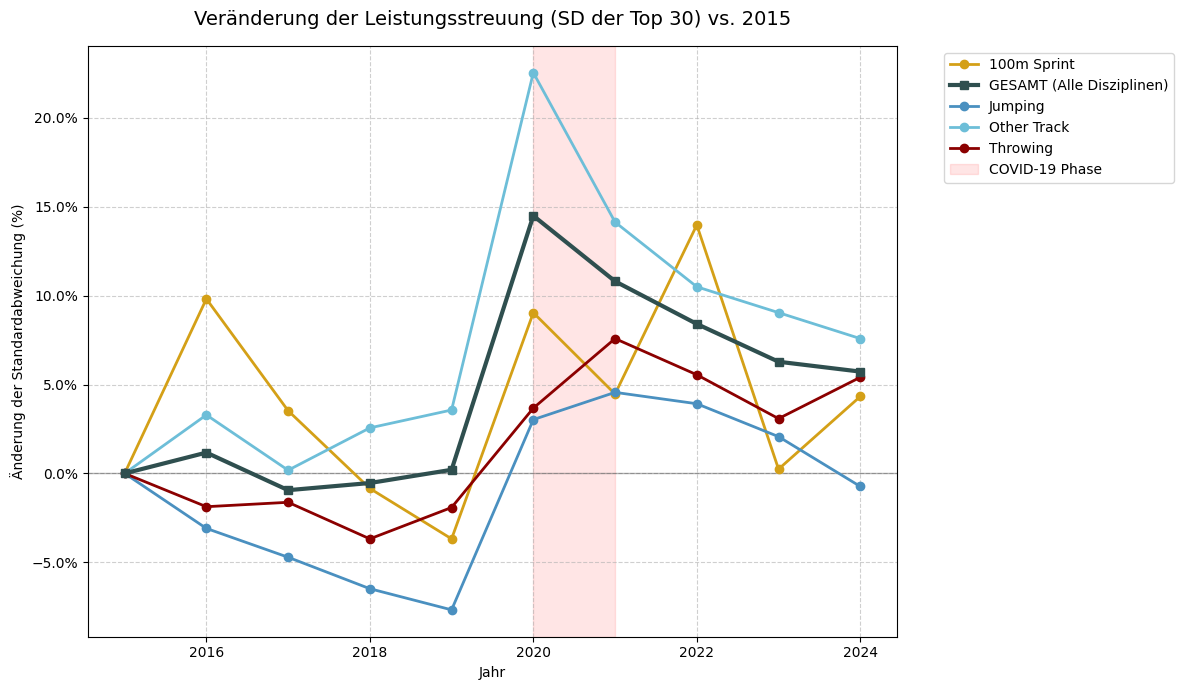

Analyse der Standardabweichung abgeschlossen.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

# Pfad zu deiner Datei
file_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy/data_csv/final_Data_iaaf_scores_neu.csv'

if not os.path.exists(file_path):
    print(f"❌ DATEI NICHT GEFUNDEN unter: {file_path}")
else:
    # 1. Daten laden
    try:
        df = pd.read_csv(file_path, sep=';')
        if df.shape[1] <= 1:
            df = pd.read_csv(file_path, sep=',')
            
        # 2. Kategorisierung
        def categorize(d):
            d = str(d).lower()
            if '100 m' in d and 'huerden' not in d: return '100m Sprint'
            if 'sprung' in d: return 'Jumping'
            if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']): return 'Throwing'
            if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']): return 'Other Track'
            return 'Combined Events'

        df['category'] = df['disziplin'].apply(categorize)
        df_recent = df[df['jahr'] >= 2015].copy()

        # 3. Standardabweichung der Top 30 berechnen
        def get_top_30_std(group):
            # Wir nehmen die Top 30 Scores und berechnen deren Standardabweichung
            return group.nlargest(30, 'iaaf_score')['iaaf_score'].std()

        # SD pro Disziplin berechnen
        top_30_std = df_recent.groupby(['jahr', 'category', 'geschlecht', 'altersklasse', 'disziplin']).apply(get_top_30_std).reset_index(name='sd_score')

        # Aggregation auf Kategorien-Ebene (Mittelwert der Standardabweichungen)
        category_sd = top_30_std.groupby(['jahr', 'category'])['sd_score'].mean().reset_index()
        
        # Gesamt-Durchschnitt der SD
        total_sd = top_30_std.groupby(['jahr'])['sd_score'].mean().reset_index()
        total_sd['category'] = 'GESAMT (Alle Disziplinen)'

        final_sd_stats = pd.concat([category_sd, total_sd], ignore_index=True)

        # 4. Prozentuale Änderung der SD (Basisjahr 2015)
        def calculate_pct_change(group):
            base_val = group.loc[group['jahr'] == 2015, 'sd_score']
            if not base_val.empty and base_val.values[0] != 0:
                b = base_val.values[0]
                group['sd_rel_change_pct'] = ((group['sd_score'] - b) / b) * 100
            else:
                group['sd_rel_change_pct'] = 0
            return group

        final_sd_stats = final_sd_stats.groupby('category', group_keys=False).apply(calculate_pct_change)

        # 5. Visualisierung
        colors = {
            '100m Sprint': '#D4A017', 'Jumping': '#4A90C0', 'Throwing': '#8B0000',
            'Other Track': '#6DBED8', 'Combined Events': '#8B6914', 'GESAMT (Alle Disziplinen)': '#2F4F4F'
        }

        fig, ax = plt.subplots(figsize=(12, 7))
        
        for cat in sorted(final_sd_stats['category'].unique()):
            cat_data = final_sd_stats[final_sd_stats['category'] == cat].sort_values('jahr')
            lw, z, marker = (3, 10, 's') if 'GESAMT' in cat else (2, 5, 'o')
            
            ax.plot(cat_data['jahr'], cat_data['sd_rel_change_pct'], 
                    label=cat, color=colors.get(cat, 'gray'), 
                    linewidth=lw, zorder=z, marker=marker)

        # Layout & Labels
        ax.axhline(0, color='black', linewidth=1, alpha=0.3)
        ax.axvspan(2020, 2021, color='red', alpha=0.1, label='COVID-19 Phase')
        
        ax.set_title('Veränderung der Leistungsstreuung (SD der Top 30) vs. 2015', fontsize=14, pad=15)
        ax.set_ylabel('Änderung der Standardabweichung (%)')
        ax.set_xlabel('Jahr')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.grid(True, linestyle='--', alpha=0.6)
        
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

        print("Analyse der Standardabweichung abgeschlossen.")

    except Exception as e:
        print(f"❌ Fehler: {e}")

/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1387/145510149.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datum'] = pd.to_datetime(df['datum'], errors='coerce')


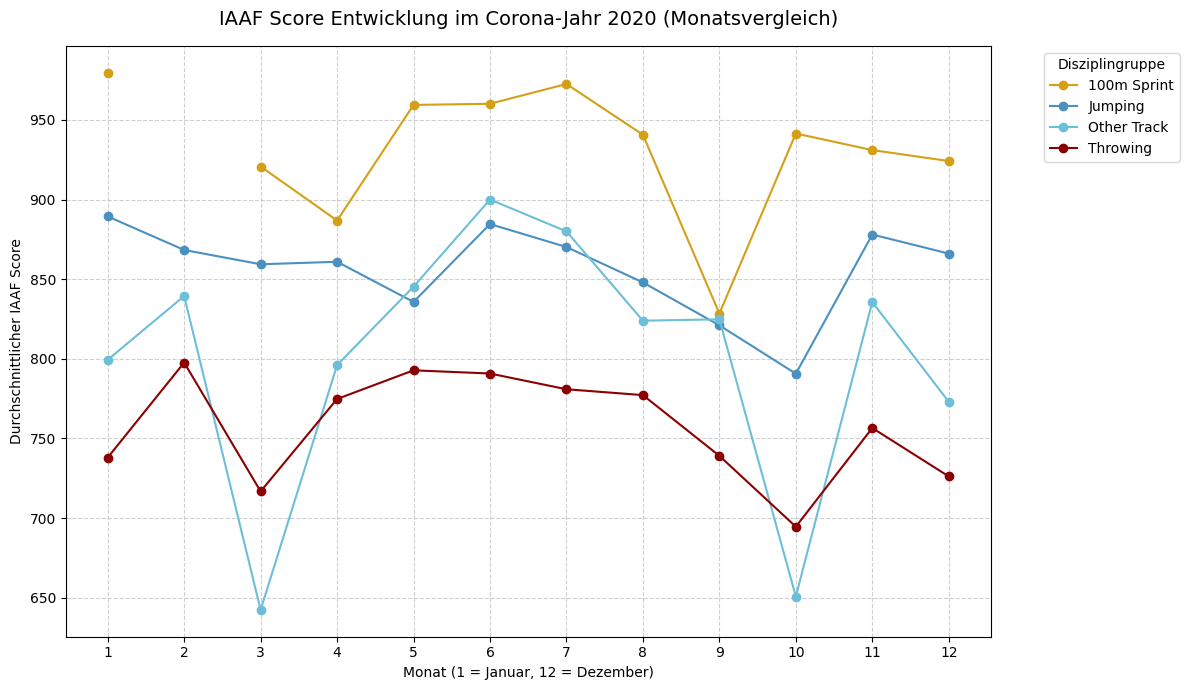

Analyse für 2020 abgeschlossen.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

# Pfad zu deiner Datei
file_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy/data_csv/final_Data_iaaf_scores_neu.csv'

if not os.path.exists(file_path):
    print(f"❌ DATEI NICHT GEFUNDEN: {file_path}")
else:
    try:
        # 1. Daten laden
        df = pd.read_csv(file_path, sep=';')
        if df.shape[1] <= 1:
            df = pd.read_csv(file_path, sep=',')

        # 2. Datum konvertieren und Monat extrahieren
        # Ich nehme an, die Spalte heißt 'datum'. Falls sie anders heißt, bitte hier anpassen:
        if 'datum' in df.columns:
            df['datum'] = pd.to_datetime(df['datum'], errors='coerce')
            df['monat'] = df['datum'].dt.month
        else:
            # Falls kein Datum vorhanden ist, sondern nur Monate als Zahlen (1-12)
            # Hier müsste man wissen, wie die Zeitinfo im Datensatz gespeichert ist.
            print("⚠️ Warnung: Keine Spalte 'datum' gefunden. Versuche alternative Spalte...")
            # Beispiel-Fallback, falls die Spalte 'monat' bereits existiert:
            if 'monat' not in df.columns:
                 raise KeyError("Die Datei benötigt eine Spalte 'datum' oder 'monat' für diese Analyse.")

        # 3. Filter auf das Jahr 2020
        df_2020 = df[df['jahr'] == 2020].copy()
        
        if df_2020.empty:
            print("❌ Keine Daten für das Jahr 2020 gefunden!")
        else:
            # 4. Kategorisierung (wie zuvor)
            def categorize(d):
                d = str(d).lower()
                if '100 m' in d and 'huerden' not in d: return '100m Sprint'
                if 'sprung' in d: return 'Jumping'
                if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']): return 'Throwing'
                if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']): return 'Other Track'
                return 'Combined Events'

            df_2020['category'] = df_2020['disziplin'].apply(categorize)

            # 5. Durchschnittlicher IAAF Score pro Monat und Kategorie
            # Wir nehmen den Mittelwert der Top-Leistungen pro Monat
            monthly_stats = df_2020.groupby(['monat', 'category'])['iaaf_score'].mean().unstack()

            # 6. Visualisierung
            fig, ax = plt.subplots(figsize=(12, 7))
            
            # Farben wie zuvor
            colors = {
                '100m Sprint': '#D4A017', 'Jumping': '#4A90C0', 'Throwing': '#8B0000',
                'Other Track': '#6DBED8', 'Combined Events': '#8B6914'
            }

            monthly_stats.plot(kind='line', marker='o', ax=ax, color=[colors.get(c, 'gray') for c in monthly_stats.columns])

            # Styling
            ax.set_title('IAAF Score Entwicklung im Corona-Jahr 2020 (Monatsvergleich)', fontsize=14, pad=15)
            ax.set_xlabel('Monat (1 = Januar, 12 = Dezember)')
            ax.set_ylabel('Durchschnittlicher IAAF Score')
            ax.set_xticks(range(1, 13))
            ax.grid(True, linestyle='--', alpha=0.6)
            
            # Legende
            ax.legend(title='Disziplingruppe', bbox_to_anchor=(1.05, 1), loc='upper left')

            plt.tight_layout()
            plt.show()
            
            print("Analyse für 2020 abgeschlossen.")

    except Exception as e:
        print(f"❌ Fehler: {e}")

✅ Projekt-Module erfolgreich geladen.


/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1387/3745099171.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datum'] = pd.to_datetime(df['datum'], errors='coerce')


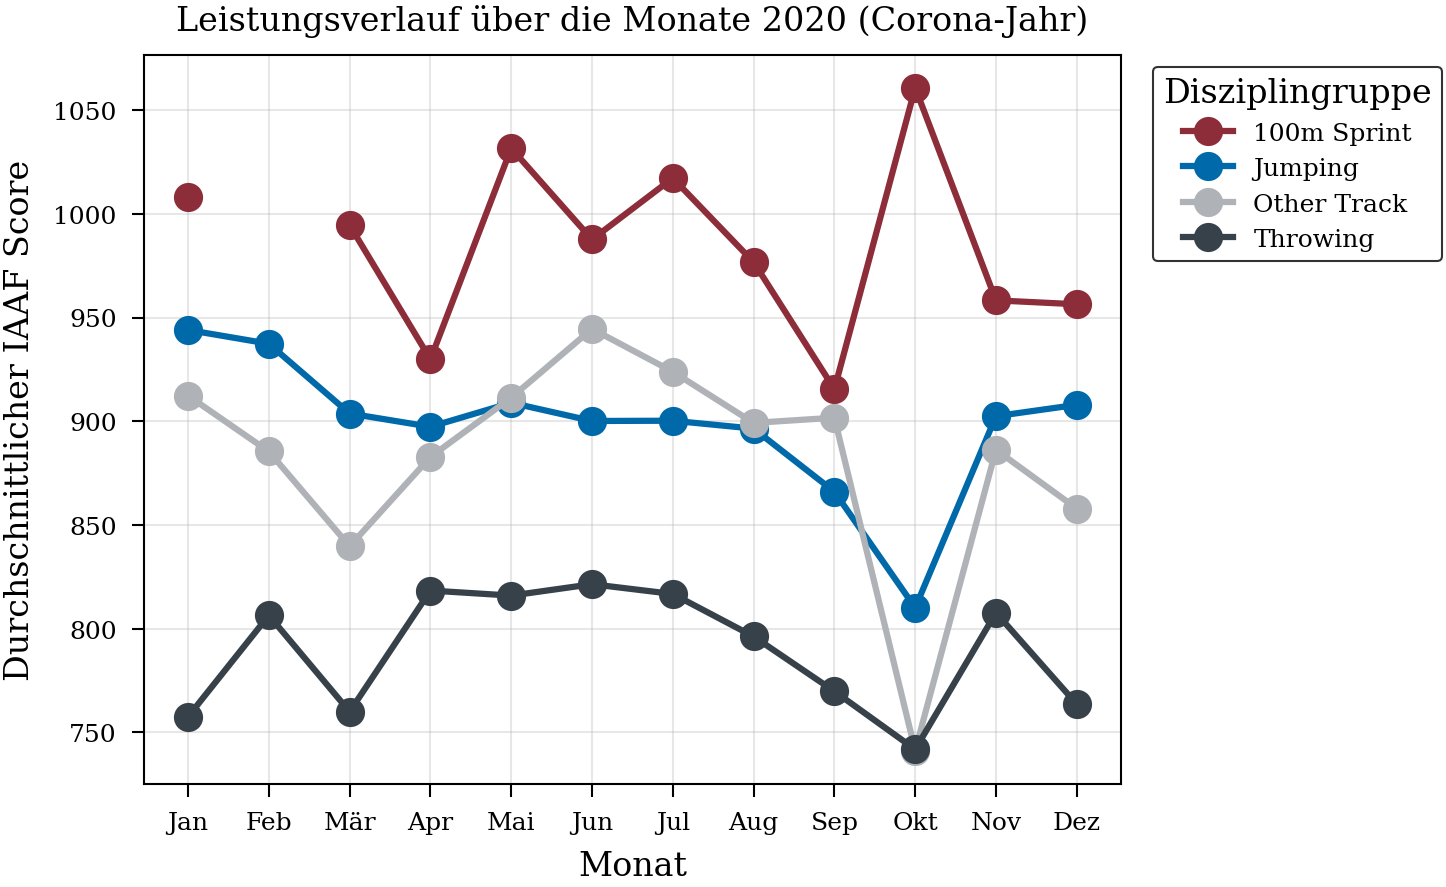

Grafik wurde im Ordner 'Plots/Corona_Impact/' gespeichert.


In [15]:
import sys
import os
import pandas as pd
import matplotlib.ticker as mtick

# --- PFAD-FIX ---
# Da util.py unter diesem Pfad liegt, fügen wir den Überordner zum Systempfad hinzu
repo_path = '/Users/snigglypoof/Documents/GitHub/Data-Literacy'
if repo_path not in sys.path:
    sys.path.append(repo_path)

# Jetzt können die Projekt-Module geladen werden
try:
    import util
    import plotting.plotting_style as plt
    from plotting.plotting_style import rgb
    print("✅ Projekt-Module erfolgreich geladen.")
except ImportError:
    print("❌ Fehler: Module konnten nicht geladen werden. Prüfe, ob der Pfad stimmt.")
    sys.exit()

# 1. Daten laden (Nutzt die interne Logik von util.py)
df = util.load_data()

# 2. Vorbereitung für monatliche Analyse 2020
# Wir stellen sicher, dass eine Datumsspalte existiert
if 'datum' not in df.columns:
    # Falls das Datum in einer anderen Spalte steckt, hier anpassen
    # Wir nehmen an, util.load_data() hat das Datum bereits bereinigt
    pass 

df['datum'] = pd.to_datetime(df['datum'], errors='coerce')
df['monat'] = df['datum'].dt.month
df['jahr'] = df['datum'].dt.year

# Filter auf das Jahr 2020
df_2020 = df[df['jahr'] == 2020].copy()

# 3. Kategorisierung (wie im Projekt definiert)
def categorize_disciplines(d):
    d = str(d).lower()
    if '100 m' in d and 'huerden' not in d: return '100m Sprint'
    if 'sprung' in d: return 'Jumping'
    if any(x in d for x in ['wurf', 'stoss', 'speer', 'hammer', 'diskus', 'kugel']): return 'Throwing'
    if any(x in d for x in ['m', 'km', 'huerden', 'hindernis', 'marathon', 'gehen']): return 'Other Track'
    return 'Combined Events'

df_2020['category'] = df_2020['disziplin'].apply(categorize_disciplines)

# 4. Berechnung: Durchschnittlicher Score pro Monat und Kategorie
monthly_stats = df_2020.groupby(['monat', 'category'])['iaaf_score'].mean().unstack()

# 5. Visualisierung im Tübingen/ICML-Style
# Wir nutzen plt.rc_context für die richtige Größe
with plt.rc_context(plt.increase_figsize(1.5)):
    fig, ax = plt.subplots()

    # Farben definieren (Tübingen Design)
    colors = {
        '100m Sprint': rgb.tue_red, 
        'Jumping': rgb.tue_blue, 
        'Throwing': rgb.tue_dark, 
        'Other Track': rgb.tue_gray, 
        'Combined Events': '#8B6914'
    }

    # Plotten der Linien
    for column in monthly_stats.columns:
        ax.plot(monthly_stats.index, monthly_stats[column], 
                label=column, 
                marker='o', 
                linewidth=1.5,
                color=colors.get(column, 'gray'))

    # Achsen-Beschriftung
    ax.set_title('Leistungsverlauf über die Monate 2020 (Corona-Jahr)')
    ax.set_xlabel('Monat')
    ax.set_ylabel('Durchschnittlicher IAAF Score')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez'])
    
    # Gitter und Legende
    ax.grid(True, alpha=0.3)
    ax.legend(title='Disziplingruppe', loc='upper left', bbox_to_anchor=(1.02, 1))

    # Automatisches Speichern im zentralen Plots/ Ordner
    plt.savefig("monatliche_analyse_2020", category="Corona_Impact")
    
    plt.show()

print("Grafik wurde im Ordner 'Plots/Corona_Impact/' gespeichert.")

/var/folders/zw/nph6kjjs0nxbnglr41zhg5w40000gn/T/ipykernel_1387/3362473967.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_sd_stats = final_sd_stats.groupby('category', group_keys=False).apply(calculate_pct_change)


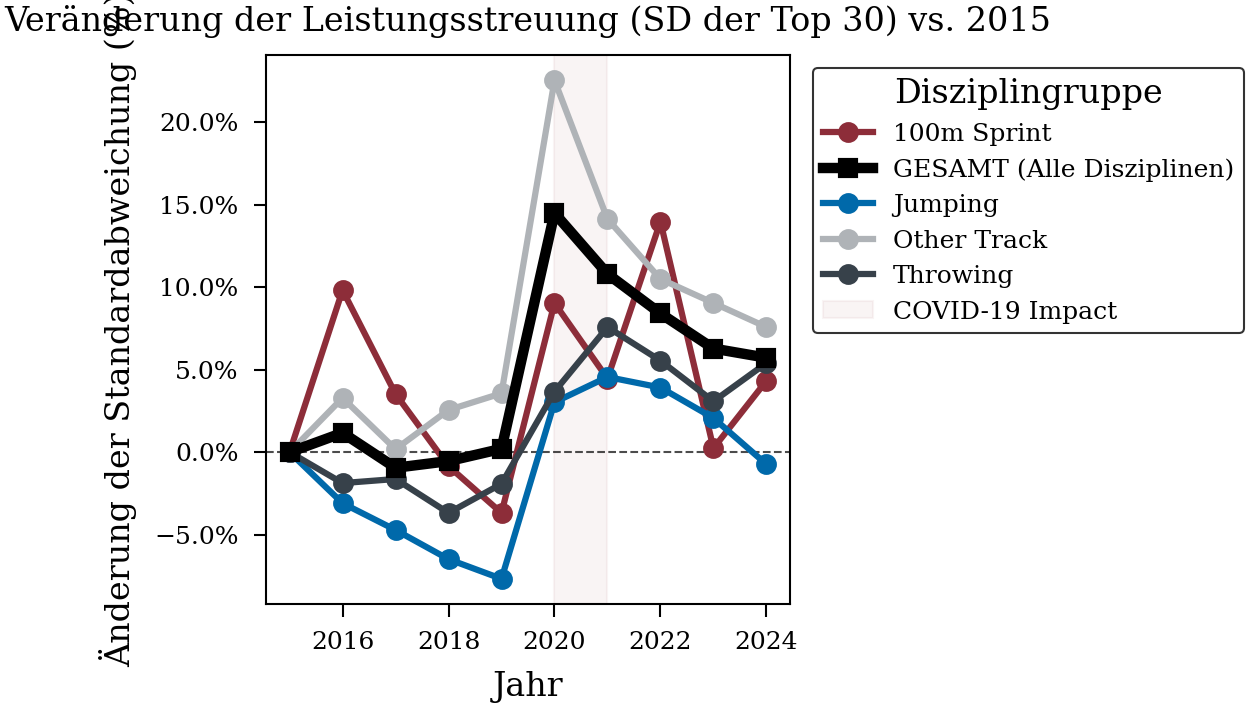

In [ ]:
# 4. Prozentuale Änderung der SD (Basisjahr 2015)
def calculate_pct_change(group):
    base_val = group.loc[group['jahr'] == 2015, 'sd_score']
    if not base_val.empty and base_val.values[0] != 0:
        b = base_val.values[0]
        group['sd_rel_change_pct'] = ((group['sd_score'] - b) / b) * 100
    else:
        group['sd_rel_change_pct'] = 0
    return group

final_sd_stats = final_sd_stats.groupby('category', group_keys=False).apply(calculate_pct_change)

# 5. Visualisierung im Tübingen/ICML-Style
with plt.rc_context(plt.increase_figsize(1.2)):
    fig, ax = plt.subplots()

    colors = {
        '100m Sprint': rgb.tue_red, 
        'Jumping': rgb.tue_blue, 
        'Throwing': rgb.tue_dark, 
        'Other Track': rgb.tue_gray, 
        'Combined Events': '#8B6914',
        'GESAMT (Alle Disziplinen)': 'black'
    }

    for cat in sorted(final_sd_stats['category'].unique()):
        cat_data = final_sd_stats[final_sd_stats['category'] == cat].sort_values('jahr')
        
        is_gesamt = 'GESAMT' in cat
        lw = 2.5 if is_gesamt else 1.5
        z = 10 if is_gesamt else 5
        marker = 's' if is_gesamt else 'o'
        
        ax.plot(cat_data['jahr'], cat_data['sd_rel_change_pct'], 
                label=cat, color=colors.get(cat, 'gray'), 
                linewidth=lw, zorder=z, marker=marker, markersize=4)

    # Layout & Labels
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.3, linestyle='--')
    ax.axvspan(2020, 2021, color=rgb.tue_red, alpha=0.05, label='COVID-19 Impact')
    
    ax.set_title('Veränderung der Leistungsstreuung (SD der Top 30) vs. 2015')
    ax.set_ylabel('Änderung der Standardabweichung (%)')
    ax.set_xlabel('Jahr')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    
    ax.legend(title='Disziplingruppe', loc='upper left', bbox_to_anchor=(1.02, 1))

    plt.savefig("standard_deviation_trends", category="Leistungsanalyse")
    plt.show()